# Logistic Regression — SMS Spam Classification

This notebook trains a Logistic Regression classifier for SMS spam
classification.

The model will use TF-IDF features generated from the preprocessed SMS
messages.

This model will be evaluated using the same train/test split and metrics
used for the Multinomial Naive Bayes baseline.

The goal is to determine whether Logistic Regression provides better
classification performance than our baseline model.

## 1. Import Required Libraries

We import the libraries required for:

- Data loading and manipulation
- TF-IDF feature extraction
- Train/test splitting
- Logistic Regression
- Model evaluation
- Visualization
- Saving model artifacts

In [1]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the SMS Dataset

The dataset contains SMS messages labelled as:

- ham → 0
- spam → 1

The CSV uses a Latin-1 compatible encoding, so we explicitly specify
the encoding when loading the dataset.

In [2]:
df = pd.read_csv("../data/spam.csv", encoding="latin-1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## 3. Prepare the Data

We will prepare the dataset for Logistic Regression.

The dataset contains several columns created by the original CSV structure.
We only need:

- `v1` → the message label
- `v2` → the SMS message

We will rename them to:

- `label`
- `message`

Then we will convert the labels:

- `ham` → `0`
- `spam` → `1`

This gives us a clean dataset that can be used for machine learning.

In [3]:
# Keep only the columns required for classification

df = df[["v1", "v2"]].copy()

# Rename columns

df.columns = ["label", "message"]

# Convert labels to numerical values

df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

# Check the prepared dataset

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nLabel distribution:")
print(df["label"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (5572, 2)

Columns:
['label', 'message']

Label distribution:
label
0    4825
1     747
Name: count, dtype: int64

Missing values:
label      0
message    0
dtype: int64


## 4. Split Features and Target

For Logistic Regression, we need to separate:

- `X` → the input text messages
- `y` → the target labels

Here:

- `X` contains the SMS messages.
- `y` contains `0` for ham and `1` for spam.

We will use these variables throughout the model training process.

In [5]:
X = df["message"]
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 messages:")
print(X.head())

print("\nFirst 5 labels:")
print(y.head())

X shape: (5572,)
y shape: (5572,)

First 5 messages:
0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: message, dtype: str

First 5 labels:
0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64


## 5. Train/Test Split

We will divide the dataset into two parts:

- **80% training data** → used to train Logistic Regression
- **20% testing data** → used to evaluate the model

We will use:

- `random_state=42` for reproducibility
- `stratify=y` to preserve the original ham/spam distribution in both sets

The text will be vectorized after the split so that the test data does not influence the vocabulary learned during training.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4457,)
X_test : (1115,)
y_train: (4457,)
y_test : (1115,)


In [7]:
print("Training labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

Training labels:
label
0    3859
1     598
Name: count, dtype: int64

Testing labels:
label
0    966
1    149
Name: count, dtype: int64


## 6. TF-IDF Vectorization

Machine learning models cannot directly work with raw text.

TF-IDF (Term Frequency–Inverse Document Frequency) converts each SMS message into a numerical vector based on the importance of its words.

We will:

1. Create a `TfidfVectorizer`.
2. Fit it only on the training messages.
3. Transform both training and testing messages.

The vectorizer learns the vocabulary from `X_train` only. This prevents information from the test set from leaking into the training process.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape :", X_test_tfidf.shape)

X_train_tfidf shape: (4457, 7701)
X_test_tfidf shape : (1115, 7701)


In [9]:
print("Number of learned features:", len(tfidf.get_feature_names_out()))

print("\nFirst 20 features:")
print(tfidf.get_feature_names_out()[:20])

Number of learned features: 7701

First 20 features:
['00' '000' '008704050406' '0089' '0121' '01223585236' '01223585334' '02'
 '0207' '02072069400' '02073162414' '02085076972' '021' '03' '04' '0430'
 '05' '050703' '0578' '06']


## 7. Train the Logistic Regression Model

We will now train a Logistic Regression classifier using the TF-IDF features.

Logistic Regression is a strong baseline model for text classification because it works well with high-dimensional sparse feature representations such as TF-IDF.

The model will learn the relationship between:

- TF-IDF features → input
- `0` / `1` labels → target

We will use `max_iter=1000` to give the optimizer enough iterations to converge.

In [10]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [11]:
print("Model type:", type(logistic_model).__name__)
print("Number of features:", logistic_model.n_features_in_)
print("Number of classes:", logistic_model.classes_)

Model type: LogisticRegression
Number of features: 7701
Number of classes: [0 1]


## 8. Make Predictions

The Logistic Regression model has now learned from the training data.

We will use it to predict the labels of the test set.

The predictions will be:

- `0` → Ham
- `1` → Spam

We will later compare these predictions with the actual `y_test` labels to evaluate the model.

In [12]:
# Make predictions on the test data

y_pred = logistic_model.predict(X_test_tfidf)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 1115


In [13]:
print("First 20 predictions:")
print(y_pred[:20])

print("\nFirst 20 actual labels:")
print(y_test.to_numpy()[:20])

First 20 predictions:
[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First 20 actual labels:
[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## 9. Evaluate the Logistic Regression Model

We will evaluate the predictions using four important classification metrics:

- **Accuracy** — percentage of all predictions that are correct.
- **Precision** — percentage of predicted spam messages that are actually spam.
- **Recall** — percentage of actual spam messages that the model successfully detects.
- **F1-score** — harmonic mean of precision and recall.

For spam detection, precision and recall are particularly important because both false positives and missed spam messages matter.

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.9722
Precision: 0.9917
Recall   : 0.7987
F1-Score : 0.8848


In [15]:
print("Percentage metrics:")

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")

Percentage metrics:
Accuracy : 97.22%
Precision: 99.17%
Recall   : 79.87%
F1-Score : 88.48%


## 10. Confusion Matrix

The confusion matrix helps us understand exactly how the Logistic Regression model is making mistakes.

It shows:

- True Negatives → Ham correctly classified as ham
- False Positives → Ham incorrectly classified as spam
- False Negatives → Spam incorrectly classified as ham
- True Positives → Spam correctly classified as spam

This is especially important for spam detection because false negatives represent spam messages that were missed by the classifier.

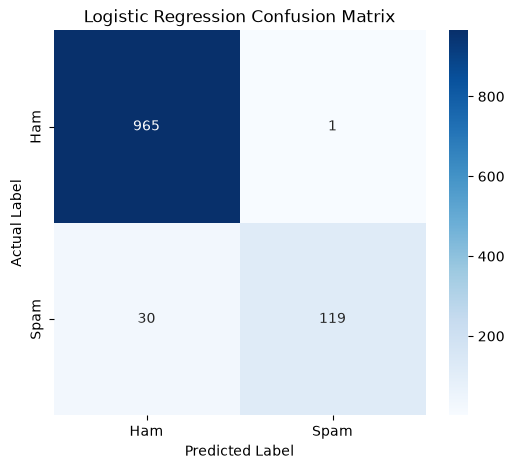

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## 11. Inspect Misclassified Spam Messages

The confusion matrix shows that 30 spam messages were incorrectly classified as ham.

These are false negatives.

Inspecting these messages helps us understand why the model failed and what kinds of spam are difficult to detect.

In [17]:
# Find spam messages incorrectly predicted as ham

false_negative_mask = (y_test.to_numpy() == 1) & (y_pred == 0)

false_negative_indices = y_test.index[false_negative_mask]

false_negatives = df.loc[false_negative_indices]

print("Number of false negatives:", len(false_negatives))

false_negatives[["label", "message"]].head(20)

Number of false negatives: 30


,label,message
5,1,FreeMsg Hey there darling it's been 3 week's n...
3748,1,Dear Voucher Holder 2 claim your 1st class air...
855,1,Talk sexy!! Make new friends or fall in love i...
1662,1,Hi if ur lookin 4 saucy daytime fun wiv busty ...
3979,1,ringtoneking 84484
3358,1,Sorry I missed your call let's talk when you h...
3546,1,Rock yr chik. Get 100's of filthy films &XXX p...
5449,1,"Latest News! Police station toilet stolen, cop..."
4614,1,Sunshine Quiz! Win a super Sony DVD recorder i...
5098,1,TheMob>Hit the link to get a premium Pink Pant...


## 12. Compare Naive Bayes vs Logistic Regression

Both models use the same TF-IDF representation and the same train/test split.

Comparing their evaluation metrics helps us determine which model performs better for the SMS spam classification task.

We will compare:

- Accuracy
- Precision
- Recall
- F1-Score

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Naive Bayes results from Day 4
nb_accuracy = 0.9686
nb_precision = 1.0000
nb_recall = 0.7651
nb_f1 = 0.8669

# Logistic Regression results from Day 5
lr_accuracy = accuracy_score(y_test, y_pred)
lr_precision = precision_score(y_test, y_pred)
lr_recall = recall_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)

print("Model Comparison")
print("-" * 60)

print(f"{'Metric':<15}{'Naive Bayes':<20}{'Logistic Regression'}")
print("-" * 60)

print(f"{'Accuracy':<15}{nb_accuracy:<20.4f}{lr_accuracy:.4f}")
print(f"{'Precision':<15}{nb_precision:<20.4f}{lr_precision:.4f}")
print(f"{'Recall':<15}{nb_recall:<20.4f}{lr_recall:.4f}")
print(f"{'F1-Score':<15}{nb_f1:<20.4f}{lr_f1:.4f}")

Model Comparison
------------------------------------------------------------
Metric         Naive Bayes         Logistic Regression
------------------------------------------------------------
Accuracy       0.9686              0.9722
Precision      1.0000              0.9917
Recall         0.7651              0.7987
F1-Score       0.8669              0.8848


## 13. Visualize Model Performance

A visual comparison makes it easier to see how Naive Bayes and Logistic Regression perform across the four evaluation metrics.

We will compare Accuracy, Precision, Recall, and F1-Score.

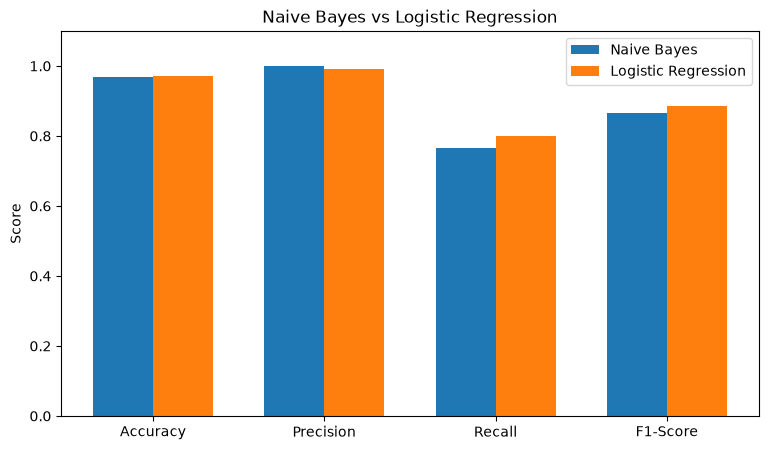

In [21]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

nb_scores = [
    nb_accuracy,
    nb_precision,
    nb_recall,
    nb_f1
]

lr_scores = [
    lr_accuracy,
    lr_precision,
    lr_recall,
    lr_f1
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, nb_scores, width, label="Naive Bayes")
plt.bar(x + width/2, lr_scores, width, label="Logistic Regression")

plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.title("Naive Bayes vs Logistic Regression")
plt.legend()

plt.show()

## 14. Save the Logistic Regression Model

The trained Logistic Regression model and TF-IDF vectorizer will be saved as reusable artifacts.

This allows the model to be loaded later for prediction without retraining.

In [22]:
import os
import joblib

# Create models directory if it does not exist
os.makedirs("../models", exist_ok=True)

# Save TF-IDF vectorizer
joblib.dump(tfidf, "../models/logistic_tfidf_vectorizer.pkl")

# Save Logistic Regression model
joblib.dump(logistic_model, "../models/logistic_regression_model.pkl")

print("Logistic Regression model artifacts saved successfully.")

Logistic Regression model artifacts saved successfully.


In [23]:
print(os.listdir("../models"))

['.gitkeep', 'logistic_regression_model.pkl', 'logistic_tfidf_vectorizer.pkl', 'naive_bayes_model.pkl', 'tfidf_vectorizer.pkl']


## 15. Reload and Test the Saved Logistic Regression Model

The trained Logistic Regression model and TF-IDF vectorizer have been saved as `.pkl` files.

We will now reload both artifacts and use them to classify new SMS messages.

This verifies that the saved model can be reused without retraining.

In [1]:
import joblib

# Load saved artifacts
loaded_tfidf = joblib.load("../models/logistic_tfidf_vectorizer.pkl")
loaded_model = joblib.load("../models/logistic_regression_model.pkl")

print("Saved model and vectorizer loaded successfully.")

Saved model and vectorizer loaded successfully.


In [2]:
# Test messages
test_messages = [
    "Congratulations! You have won a free prize. Call now!",
    "Hey, are we still meeting for lunch today?"
]

# Transform messages using the saved vectorizer
test_vectors = loaded_tfidf.transform(test_messages)

# Predict using the saved model
test_predictions = loaded_model.predict(test_vectors)

for message, prediction in zip(test_messages, test_predictions):
    label = "SPAM" if prediction == 1 else "HAM"
    print(f"Message: {message}")
    print(f"Prediction: {label}")
    print("-" * 60)

Message: Congratulations! You have won a free prize. Call now!
Prediction: SPAM
------------------------------------------------------------
Message: Hey, are we still meeting for lunch today?
Prediction: HAM
------------------------------------------------------------
